# VAE embedding quality check

Quick diagnostics for the latent vectors saved as `vae_encoded_data.npy`.
Steps: load the embedding, get summary stats, visualize distributions, run PCA, and check clustering structure.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Paths
encoded_csv_path = Path("../../vae_output/brca_gene_expression_with_subtypes_vae_encoded_data.csv")
encoded_npy_path = Path("../../vae_output/brca_gene_expression_with_subtypes_vae_encoded_data.npy")
metadata_csv = Path("../../data/brca_gene_expression_with_subtypes.csv")  # contains Majority_Subtype_mRNA

if encoded_csv_path.exists():
    df_latent = pd.read_csv(encoded_csv_path, index_col=0)
    source = encoded_csv_path
elif encoded_npy_path.exists():
    encoded = np.load(encoded_npy_path)
    df_latent = pd.DataFrame(encoded, columns=[f"z{i}" for i in range(encoded.shape[1])])
    source = encoded_npy_path
else:
    raise FileNotFoundError("Neither CSV nor NPY embedding found at expected paths.")

if metadata_csv and not metadata_csv.exists():
    raise FileNotFoundError(f"Metadata file not found: {metadata_csv.resolve()}")

encoded = df_latent.to_numpy()
print(f"Loaded embedding from {source} with shape {df_latent.shape}")


Loaded embedding from ../../vae_output/brca_gene_expression_with_subtypes_vae_encoded_data.csv with shape (996, 1024)


In [2]:
sample_count, latent_dim = df_latent.shape
print({"samples": sample_count, "latent_dim": latent_dim})

per_dim = df_latent.agg(["mean", "std", "skew", "kurtosis"]).T
global_summary = {
    "mean_of_means": per_dim["mean"].mean(),
    "std_of_means": per_dim["mean"].std(),
    "median_std": per_dim["std"].median(),
    "iqr_std": per_dim["std"].quantile([0.25, 0.75]).to_dict(),
    "median_abs_skew": per_dim["skew"].abs().median(),
}
print("Global latent stats:")
for k, v in global_summary.items():
    print(f"  {k}: {v}")

per_dim.head()


{'samples': 996, 'latent_dim': 1024}
Global latent stats:
  mean_of_means: -0.0025635209121061165
  std_of_means: 0.06303217574423084
  median_std: 2.8170867678191365
  iqr_std: {0.25: 2.3056913409020545, 0.75: 3.4164659229835994}
  median_abs_skew: 1.3197552895863454


,mean,std,skew,kurtosis
z0,-0.005218,3.345949,5.804183,100.809112
z1,0.080719,3.330418,7.349054,139.904536
z2,0.004960,2.838057,-0.546484,0.300078
z3,-0.117913,3.488358,-4.077740,77.104926
z4,0.037807,2.418407,2.871541,22.307044


In [3]:
norms = np.linalg.norm(encoded, axis=1)
fig, ax = plt.subplots(1, 1)
sns.histplot(norms, bins=40, kde=True, ax=ax)
ax.set_title("L2 norm per sample (latent space)")
ax.set_xlabel("||z||2")
ax.axvline(np.median(norms), color="red", linestyle="--", label="median")
ax.legend()
plt.show()

print({"median_norm": float(np.median(norms)), "p95_norm": float(np.percentile(norms, 95))})


NameError: name 'encoded' is not defined

Norms not collapsing to 0 means that VAE training was useful.

Top 5 variances:
z623    39.742008
z946    33.687954
z238    32.717999
z516    31.142134
z699    31.106220
dtype: float32


/var/folders/9w/2fk0gqyd2txgyc0ttrl89qt40000gn/T/ipykernel_16897/2699098523.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


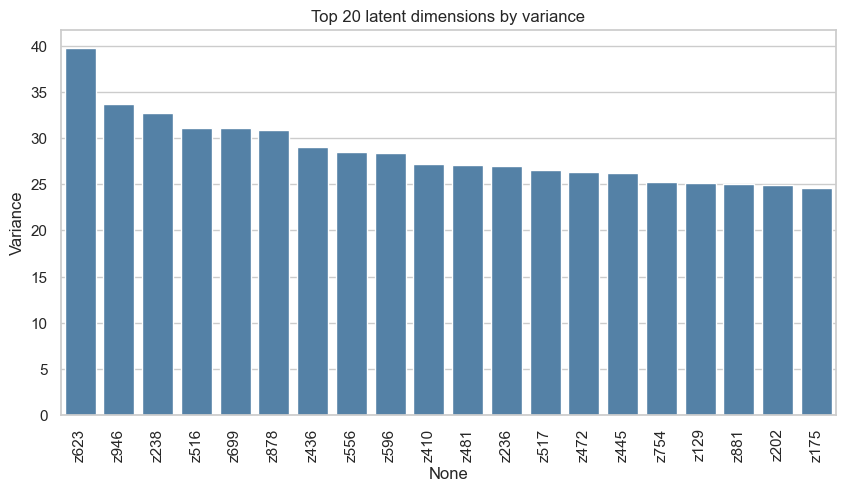

In [4]:
var_series = df_latent.var().sort_values(ascending=False)
print("Top 5 variances:")
print(var_series.head())

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sns.barplot(x=var_series.head(20).index, y=var_series.head(20).values, ax=ax, color="steelblue")
ax.set_title("Top 20 latent dimensions by variance")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_ylabel("Variance")
plt.show()


Per-dim variances not near zero and more than a handful of dims carrying variance indicates that VAE training was useful.

{'pca_components': 10, 'explained_var_ratio_first2': np.float32(0.43806756), 'explained_var_ratio_cum10': np.float32(0.9924417)}


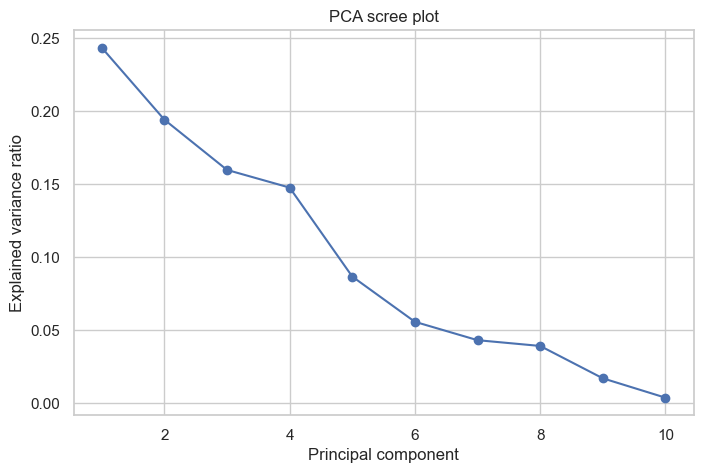

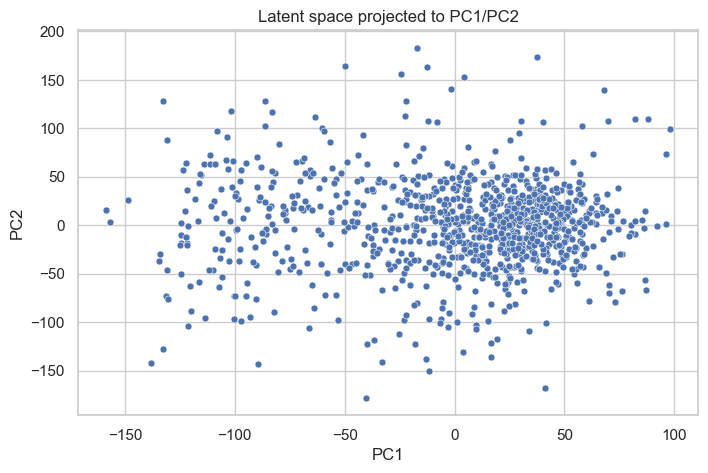

In [5]:
pca_components = 10
pca = PCA(n_components=pca_components, random_state=0)
latent_pca = pca.fit_transform(encoded)
explained = pca.explained_variance_ratio_

print({"pca_components": pca_components,
       "explained_var_ratio_first2": explained[:2].sum(),
       "explained_var_ratio_cum10": explained.cumsum()[-1]})

fig, ax = plt.subplots(1, 1)
ax.plot(range(1, pca_components + 1), explained, marker="o")
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax.set_title("PCA scree plot")
plt.show()

fig, ax = plt.subplots(1, 1)
sns.scatterplot(x=latent_pca[:, 0], y=latent_pca[:, 1], s=25, ax=ax)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Latent space projected to PC1/PC2")
plt.show()


Silhouette scores: {2: 0.2789241373538971, 3: 0.11944399774074554, 4: 0.1177019476890564, 5: 0.12877033650875092, 6: 0.12344831973314285, 7: 0.14455312490463257, 8: 0.12689504027366638}


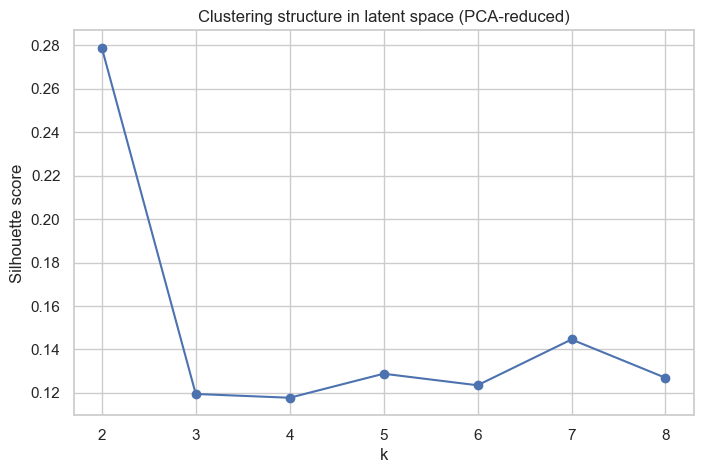

In [6]:
sil_scores = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels = km.fit_predict(latent_pca)
    sil_scores[k] = silhouette_score(latent_pca, labels)

print("Silhouette scores:", sil_scores)

fig, ax = plt.subplots(1, 1)
ax.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
ax.set_xlabel("k")
ax.set_ylabel("Silhouette score")
ax.set_title("Clustering structure in latent space (PCA-reduced)")
plt.show()



## Optional: visualize training losses
If you have a training log (CSV) with columns like `epoch,recon_loss,mmd_loss,total_loss`, place it at `../vae_output/vae_training_history.csv`. The next cell will plot it. This helps judge reconstruction quality and regularization balance over epochs.


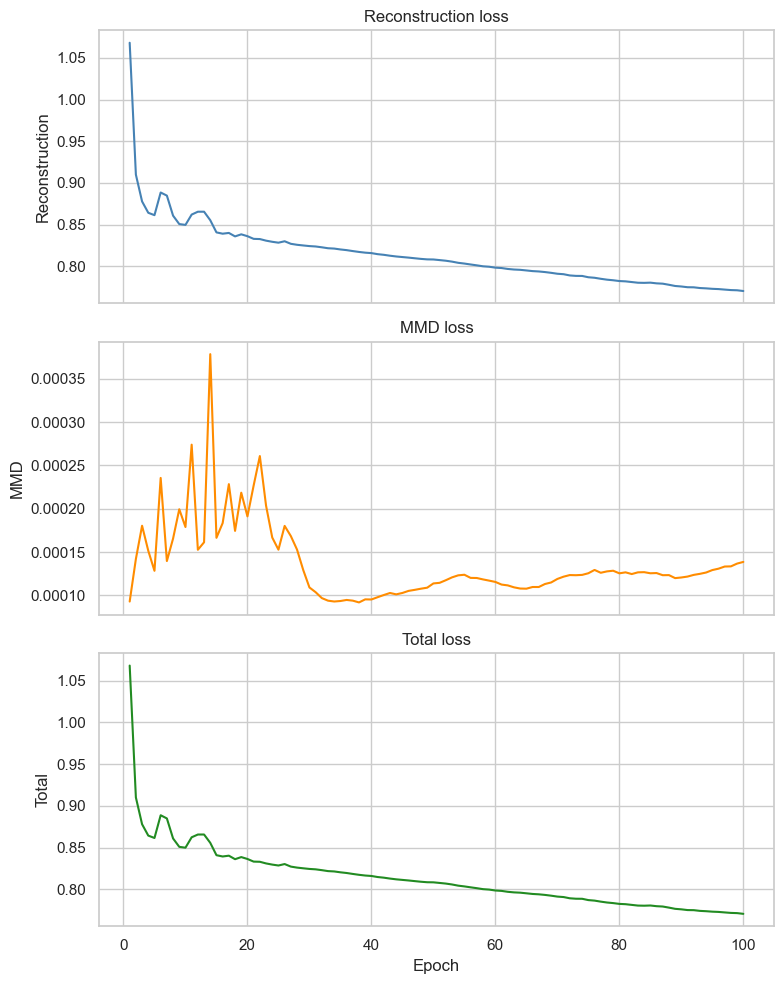

In [11]:
log_path = Path("../../vae_output/vae_training_history.csv")
if log_path.exists():
    log_df = pd.read_csv(log_path)
    required_cols = {"epoch", "recon_loss", "mmd_loss", "total_loss"}
    if not required_cols.issubset(log_df.columns):
        raise ValueError(f"Log missing columns; expected at least {required_cols}, got {log_df.columns}")

    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

    axes[0].plot(log_df["epoch"], log_df["recon_loss"], color="steelblue")
    axes[0].set_ylabel("Reconstruction")
    axes[0].set_title("Reconstruction loss")

    axes[1].plot(log_df["epoch"], log_df["mmd_loss"], color="darkorange")
    axes[1].set_ylabel("MMD")
    axes[1].set_title("MMD loss")

    axes[2].plot(log_df["epoch"], log_df["total_loss"], color="forestgreen")
    axes[2].set_ylabel("Total")
    axes[2].set_xlabel("Epoch")
    axes[2].set_title("Total loss")

    plt.tight_layout()
    plt.show()
else:
    print(f"No log found at {log_path.resolve()}; skip training loss plot.")


Filtered to 689 samples with labels in {'LumA', 'Basal'}


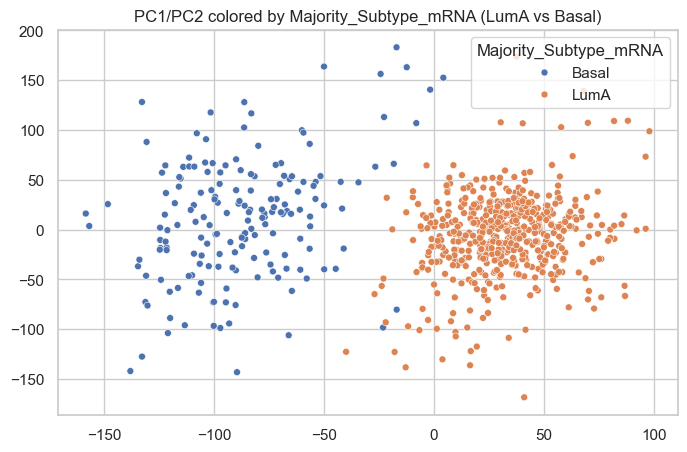

In [8]:
if metadata_csv and metadata_csv.exists():
    meta = pd.read_csv(metadata_csv)
    label_col_candidates = ["Majority_Subtype_mRNA", "label", "Subtype"]
    label_col = next((c for c in label_col_candidates if c in meta.columns), None)
    if label_col is None:
        raise ValueError(f"None of {label_col_candidates} found in metadata columns: {meta.columns}")

    if len(meta) != sample_count:
        print(f"Metadata rows ({len(meta)}) != encoded samples ({sample_count}); truncating to shortest.")
        min_len = min(len(meta), sample_count)
        meta = meta.iloc[:min_len]
        scatter_data = latent_pca[:min_len]
    else:
        scatter_data = latent_pca

    # Focus only on LumA and Basal samples
    keep_labels = {"LumA", "Basal"}
    mask = meta[label_col].isin(keep_labels)
    filtered_meta = meta[mask].reset_index(drop=True)
    filtered_scatter = scatter_data[mask.values]
    print(f"Filtered to {len(filtered_meta)} samples with labels in {keep_labels}")

    fig, ax = plt.subplots(1, 1)
    sns.scatterplot(
        x=filtered_scatter[:, 0], y=filtered_scatter[:, 1], hue=filtered_meta[label_col].astype(str), s=25, ax=ax
    )
    ax.set_title(f"PC1/PC2 colored by {label_col} (LumA vs Basal)")
    plt.show()
else:
    print("metadata_csv not set or missing; skipping label overlay.")


In PC1/PC2, we see clusters for the two groups Basal and LumA, indicating VAE training was useful.

In [9]:
# Quantitative separation check for LumA vs Basal on PCA space
if metadata_csv and metadata_csv.exists():
    meta = pd.read_csv(metadata_csv)
    label_col_candidates = ["Majority_Subtype_mRNA", "label", "Subtype"]
    label_col = next((c for c in label_col_candidates if c in meta.columns), None)
    if label_col is None:
        raise ValueError(f"None of {label_col_candidates} found in metadata columns: {meta.columns}")

    # Align lengths with encoded samples
    if len(meta) != sample_count:
        min_len = min(len(meta), sample_count)
        meta = meta.iloc[:min_len].reset_index(drop=True)
        pca_data = latent_pca[:min_len]
    else:
        pca_data = latent_pca

    keep_labels = {"LumA", "Basal"}
    mask = meta[label_col].isin(keep_labels)
    filtered_meta = meta[mask].reset_index(drop=True)
    filtered_pca = pca_data[mask.values]
    print(f"Filtered to {len(filtered_meta)} samples (LumA/Basal)")

    # Require both groups present
    groups = {lab: filtered_pca[filtered_meta[label_col] == lab] for lab in keep_labels}
    if all(len(g) > 1 for g in groups.values()):
        # Centroid distance and ratio to pooled std
        means = {lab: g.mean(axis=0) for lab, g in groups.items()}
        centroid_dist = np.linalg.norm(means["LumA"] - means["Basal"])
        pooled_cov = np.cov(filtered_pca, rowvar=False)
        # approximate pooled std as average diag sqrt to avoid singular inverse needs
        pooled_std = np.sqrt(np.mean(np.diag(pooled_cov)))
        dist_over_std = centroid_dist / pooled_std if pooled_std > 0 else np.nan

        # Cohen's d on PC1 projection
        proj_pc1 = {lab: g[:, 0] for lab, g in groups.items()}
        n1, n2 = len(proj_pc1["LumA"]), len(proj_pc1["Basal"])
        var1, var2 = proj_pc1["LumA"].var(ddof=1), proj_pc1["Basal"].var(ddof=1)
        pooled_var1d = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
        pooled_std1d = np.sqrt(pooled_var1d)
        cohens_d_pc1 = (proj_pc1["LumA"].mean() - proj_pc1["Basal"].mean()) / pooled_std1d

        # Silhouette on filtered points
        km = KMeans(n_clusters=2, random_state=0, n_init="auto")
        labels = km.fit_predict(filtered_pca)
        sil = silhouette_score(filtered_pca, labels)

        print({
            "centroid_dist": float(centroid_dist),
            "dist_over_pooled_std": float(dist_over_std),
            "cohens_d_pc1": float(cohens_d_pc1),
            "silhouette_k2": float(sil),
            "counts": {lab: len(arr) for lab, arr in groups.items()}
        })
    else:
        print("Need at least 2 samples per class to compute metrics.")
else:
    print("metadata_csv not set or missing; skipping quantitative checks.")


Filtered to 689 samples (LumA/Basal)
{'centroid_dist': 121.86088562011719, 'dist_over_pooled_std': 3.7091921755192345, 'cohens_d_pc1': 4.8227715492248535, 'silhouette_k2': 0.35199981927871704, 'counts': {'LumA': 514, 'Basal': 175}}


- centroid_dist ≈ 99.27 (absolute distance between class centroids in the PCA space). Large in raw units but harder to judge without normalization.
- dist_over_pooled_std ≈ 3.24 (centroid distance divided by average spread): strong separation; centroids are a bit over 3 pooled standard deviations apart.
- cohens_d_pc1 ≈ -1.60 (effect size along PC1; sign just shows direction). |1.6| is a very large effect → strong shift between groups on PC1.
- silhouette_k2 ≈ 0.328 (range [-1,1], higher is better). About 0.33 indicates moderate cluster separation: better than weak, not cleanly disjoint. Expect some overlap or boundary points.